# Deep Learning

Image processing


In [72]:
import os
import zipfile
import requests


In [73]:
url = "https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip"
zip_path = "../data/raw/dogs-vs-cats.zip"

os.makedirs("../data/raw", exist_ok=True)

response = requests.get(url)

with open(zip_path, "wb") as file:
    file.write(response.content)

In [74]:
extract_path = "../data/raw/dogs-vs-cats"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [75]:
import os

train_path = "../data/raw/dogs-vs-cats/dogs-vs-cats/train"

In [76]:
files = os.listdir(train_path)

print("Number of images:", len(files))
print(files[:10])

Number of images: 25000
['dog.8011.jpg', 'cat.5077.jpg', 'dog.7322.jpg', 'cat.2718.jpg', 'cat.10151.jpg', 'cat.3406.jpg', 'dog.1753.jpg', 'cat.4369.jpg', 'cat.7660.jpg', 'dog.5535.jpg']


In [77]:
cat_files = [f for f in files if f.startswith("cat.")]
dog_files = [f for f in files if f.startswith("dog.")]

print("Cats:", len(cat_files))
print("Dogs:", len(dog_files))

Cats: 12500
Dogs: 12500


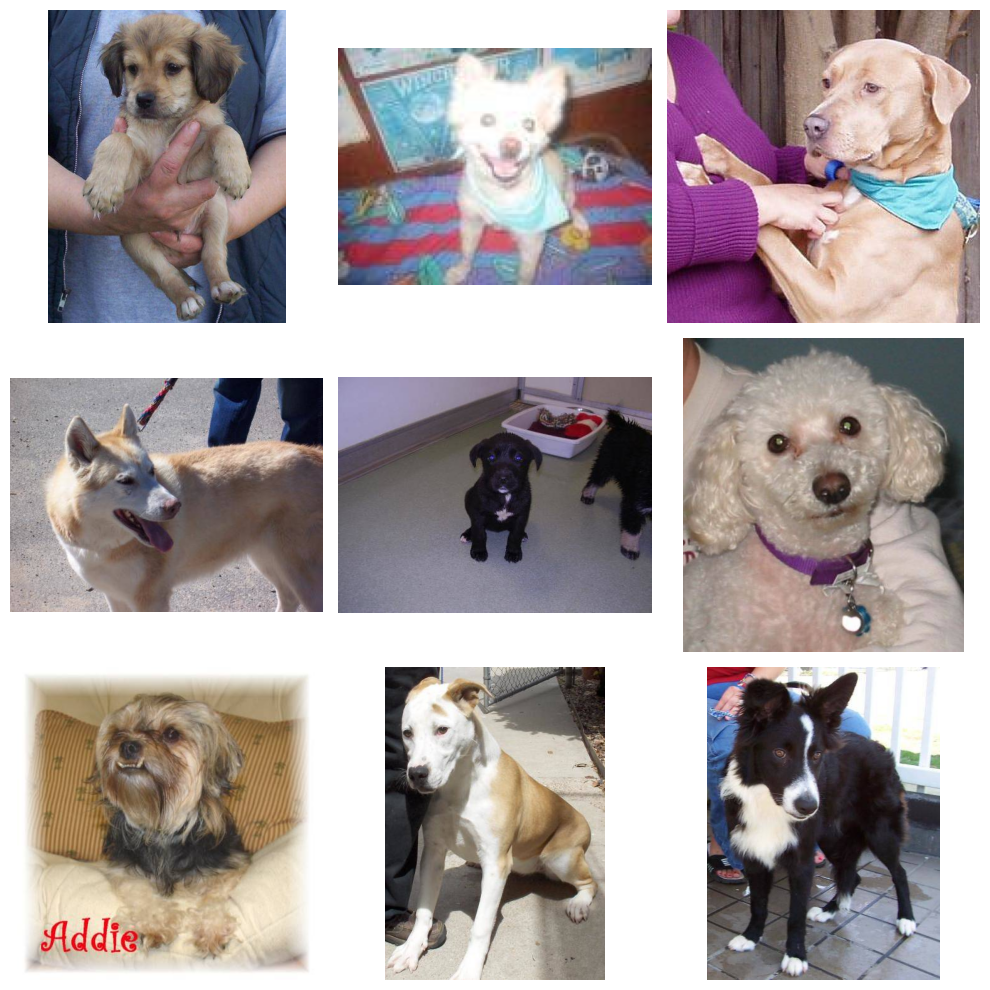

In [78]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    img = load_img(os.path.join(train_path, dog_files[i]))

    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

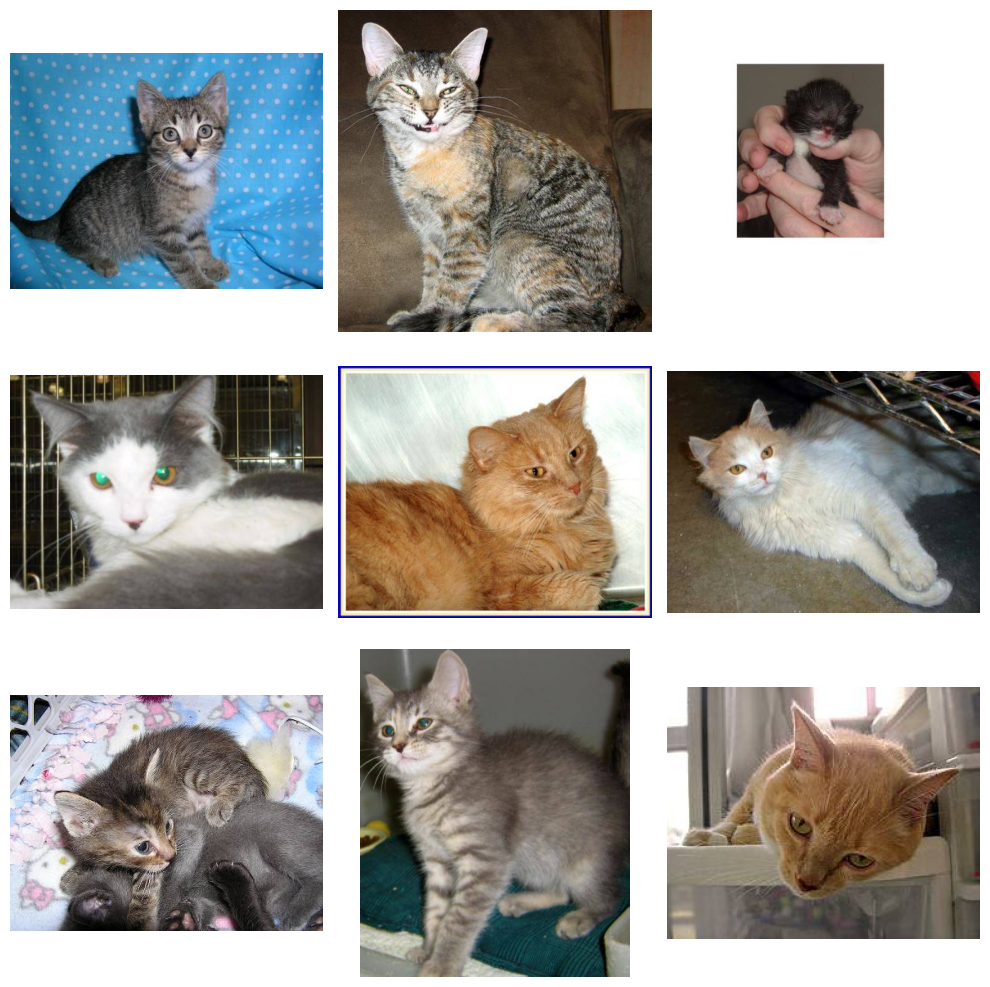

In [79]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    img = load_img(os.path.join(train_path, cat_files[i]))

    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

Original image size: (380, 500)


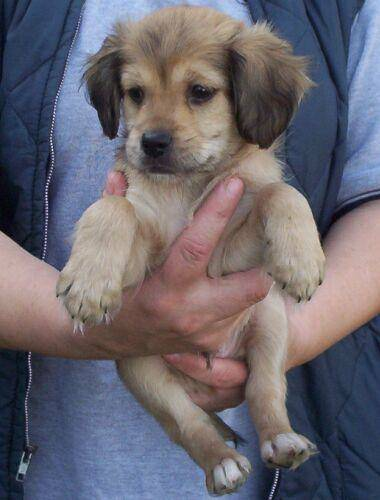

In [80]:
from tensorflow.keras.preprocessing.image import img_to_array

sample_path = os.path.join(train_path, dog_files[0])

img = load_img(sample_path)

print("Original image size:", img.size)

img

In [81]:
img_array = img_to_array(img)

print("Array shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Array shape: (500, 380, 3)
Data type: float32
Minimum pixel value: 0.0
Maximum pixel value: 255.0


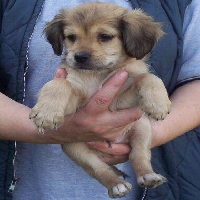

In [82]:
img_resized = load_img(
    sample_path,
    target_size=(200, 200)
)

img_resized


In [83]:
resized_array = img_to_array(img_resized)

print("Resized shape:", resized_array.shape)

Resized shape: (200, 200, 3)


In [84]:
resized_array = resized_array / 255.0

In [85]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [86]:
X = np.empty(
    (len(files), 200, 200, 3),
    dtype=np.uint8
)

y = np.empty(
    len(files),
    dtype=np.uint8
)

In [87]:
for i, filename in enumerate(files):

    # Build the full path to the image
    img_path = os.path.join(train_path, filename)

    # Open the image and resize it to 200 × 200
    img = load_img(
        img_path,
        target_size=(200, 200)
    )

    # Convert the image into numerical pixel values
    X[i] = img_to_array(img).astype(np.uint8)

    # Create the label from the filename
    if filename.startswith("cat."):
        y[i] = 0
    else:
        y[i] = 1

In [88]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print("Cats:", np.sum(y == 0))
print("Dogs:", np.sum(y == 1))

X shape: (25000, 200, 200, 3)
y shape: (25000,)
X dtype: uint8
y dtype: uint8
Cats: 12500
Dogs: 12500


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Training cats:", (y_train == 0).sum())
print("Training dogs:", (y_train == 1).sum())

print("Testing cats:", (y_test == 0).sum())
print("Testing dogs:", (y_test == 1).sum())

X_train: (20000, 200, 200, 3)
X_test: (5000, 200, 200, 3)
y_train: (20000,)
y_test: (5000,)
Training cats: 10000
Training dogs: 10000
Testing cats: 2500
Testing dogs: 2500


In [91]:
from tensorflow.keras.layers import Rescaling

Rescaling(1./255)

<Rescaling name=rescaling_5, built=False>

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [93]:
model = Sequential([
    
    Rescaling(
        1./255,
        input_shape=(200, 200, 3)
    ),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [94]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,894,017 (72.07 MB)

 Trainable params: 18,894,017 (72.07 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
 68/500 ━━━━━━━━━━━━━━━━━━━━ 50s 117ms/step - accuracy: 0.5795 - loss: 0.7569

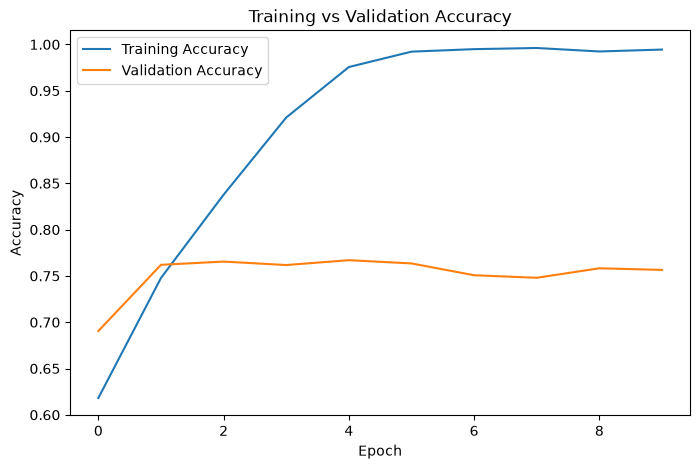

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

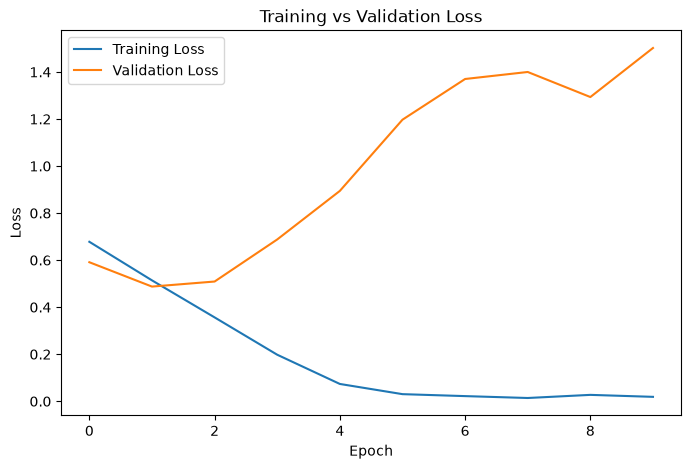

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


## Model "Optimization"

In [ ]:
from tensorflow.keras.layers import (
    Rescaling,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense
)

In [ ]:
model_v2 = Sequential([

    # Data augmentation
    RandomFlip(
        "horizontal",
        input_shape=(200, 200, 3)
    ),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Pixel normalization: 0-255 → 0-1
    Rescaling(1./255),

    # First convolutional block
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolutional block
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Replace Flatten with Global Average Pooling
    GlobalAveragePooling2D(),

    # Classification layers
    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 200, 200, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_v2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import os

os.makedirs("../models", exist_ok=True)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../models/best_cnn_v2.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
history_v2 = model_v2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.5634 - loss: 0.6778 - val_accuracy: 0.6120 - val_loss: 0.6518
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6056 - loss: 0.6528 - val_accuracy: 0.5985 - val_loss: 0.6571
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6185 - loss: 0.6438 - val_accuracy: 0.6190 - val_loss: 0.6380
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6381 - loss: 0.6280 - val_accuracy: 0.6450 - val_loss: 0.6239
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.6626 - loss: 0.6123 - val_accuracy: 0.6758 - val_loss: 0.5946
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6764 - loss: 0.6002 - val_accuracy: 0.6780 - val_loss: 0.5871
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6887 - loss: 0.5884 - val_accuracy: 0.6670 - val_loss: 0.6032
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6927 - loss: 0

In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
model_v3 = Sequential([
    Input(shape=(200, 200, 3)),

    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    Rescaling(1./255),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [ ]:
model_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 200, 200, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_v3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping_v3 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_v3 = ModelCheckpoint(
    "../models/best_cnn_v3.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
history_v3 = model_v3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        early_stopping_v3,
        checkpoint_v3
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 163ms/step - accuracy: 0.5694 - loss: 0.6725 - val_accuracy: 0.5815 - val_loss: 0.6723
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.5992 - loss: 0.6565 - val_accuracy: 0.5755 - val_loss: 0.6663
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 162ms/step - accuracy: 0.6414 - loss: 0.6282 - val_accuracy: 0.6562 - val_loss: 0.6146
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 162ms/step - accuracy: 0.6777 - loss: 0.5972 - val_accuracy: 0.7048 - val_loss: 0.5689
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.6988 - loss: 0.5737 - val_accuracy: 0.7132 - val_loss: 0.5625
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.7070 - loss: 0.5589 - val_accuracy: 0.7330 - val_loss: 0.5315
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 163ms/step - accuracy: 0.7201 - loss: 0.5397 - val_accuracy: 0.7347 - val_loss: 0.5180
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.7343 - loss: 0

v1 had very low training error but poor generalization. 

v2 generalized consistently, but it simply did not have enough feature-extraction capacity to separate cats from dogs particularly well.

v3 added more convolutional capacity without bringing back the huge Dense layer, and that seems to have worked.

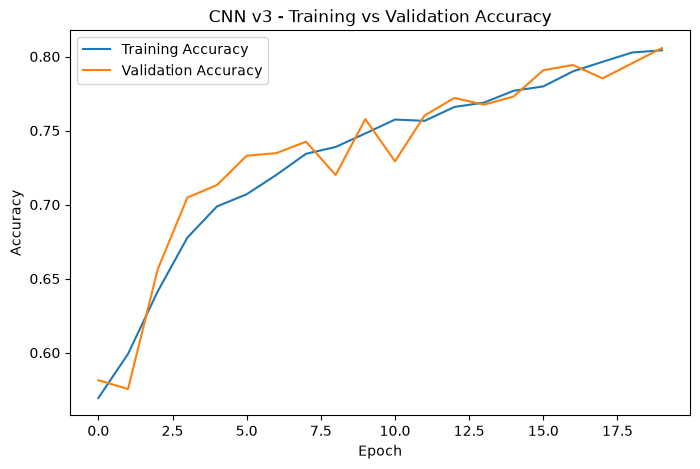

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_v3.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_v3.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN v3 - Training vs Validation Accuracy")
plt.legend()
plt.show()

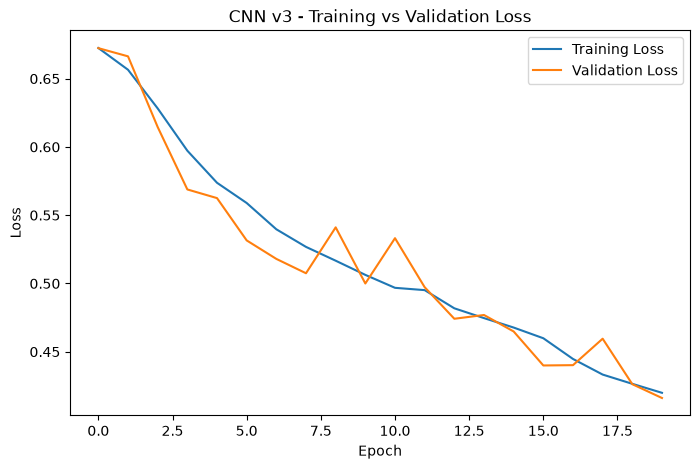

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_v3.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_v3.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN v3 - Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model_v3.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8096 - loss: 0.4226
Test Loss: 0.42263373732566833
Test Accuracy: 0.8095999956130981


In [ ]:
model_v3.save("../models/final_cnn_model.keras")

In [ ]:
predictions = model_v3.predict(X_test)

print(predictions.shape)
print(predictions[:5])

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step
(5000, 1)
[[0.9576261 ]
 [0.18734862]
 [0.04200309]
 [0.09275981]
 [0.8925077 ]]


In [ ]:
predicted_classes = (predictions > 0.5).astype(int).flatten()

print(predicted_classes[:10])
print(y_test[:10])

[1 0 0 0 1 0 0 1 0 1]
[1 1 0 0 1 0 1 0 0 1]


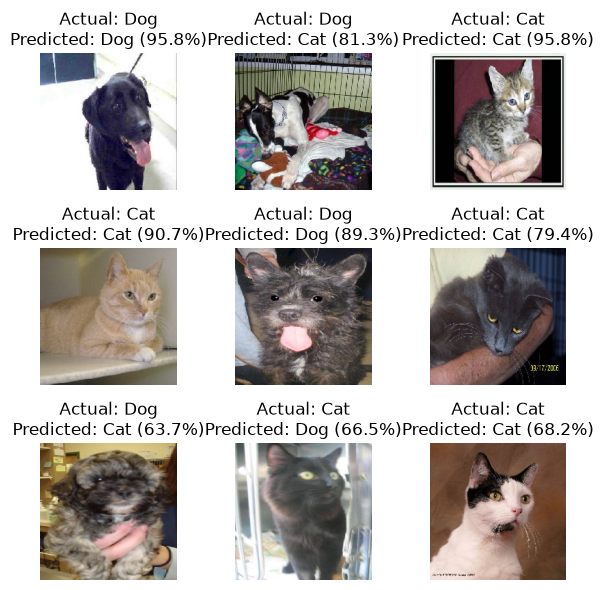

In [ ]:
plt.figure(figsize=(6, 6))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_test[i])

    actual = "Dog" if y_test[i] == 1 else "Cat"
    predicted = "Dog" if predicted_classes[i] == 1 else "Cat"

    probability_dog = predictions[i][0]

    if predicted == "Dog":
        confidence = probability_dog
    else:
        confidence = 1 - probability_dog

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted} ({confidence:.1%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import json

with open("../models/cnn_v3_history.json", "w") as f:
    json.dump(history_v3.history, f)

## Model Evaluation and Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to classify images as either cats or dogs. The original images had different dimensions, so all images were resized to **200 × 200 pixels** and represented as RGB arrays. The dataset contained **25,000 images**, evenly divided between 12,500 cats and 12,500 dogs.

The data was split into:
- **20,000 training images**
- **5,000 testing images**

The training data was further divided internally to create a validation set during model training.

### Model Development

Several CNN architectures were explored to understand the relationship between model complexity, overfitting, and generalization.

The first CNN used two convolutional layers followed by `Flatten()` and a large Dense layer. This model contained approximately **18.9 million parameters**. Training accuracy increased to approximately **99%**, while validation accuracy remained around **76%**. Validation loss also increased substantially while training loss approached zero, indicating strong **overfitting**.

A second CNN replaced `Flatten()` with `GlobalAveragePooling2D()` and introduced data augmentation using random horizontal flips, rotations, and zooms. This reduced the model to approximately **27,800 parameters** and greatly reduced overfitting. However, both training and validation accuracy remained around **71–72%**, suggesting that the model had insufficient capacity.

A third CNN added an additional convolutional block with 128 filters while retaining data augmentation and global average pooling. This increased the model to approximately **109,900 parameters**, providing a better balance between model capacity and generalization.

### Final Model Performance

The final CNN achieved approximately:

- **Training accuracy:** 80.4%
- **Validation accuracy:** 80.6%
- **Test accuracy:** 81.0%
- **Test loss:** 0.423

Training and validation curves remained close throughout training, while both losses generally decreased together. This indicates that the final model generalized considerably better than the original CNN and showed little evidence of significant overfitting.

The model was evaluated on **5,000 previously unseen test images**, achieving a final test accuracy of **80.96%**.

### Key Takeaways

This project demonstrated how CNNs automatically learn hierarchical visual features directly from image pixels. Convolutional layers were used for feature extraction, pooling reduced spatial dimensions, and the final layers performed binary classification.

The experiments also demonstrated that increasing model complexity does not necessarily improve performance. The original model was powerful enough to memorize the training data but generalized poorly. Data augmentation, global average pooling, and a more appropriate model capacity produced a substantially better balance between training and unseen-data performance.

The final model was saved for future inference and can predict whether a new image represents a cat or dog.